<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Fama%2C%20E.%20F.%2C%20%26%20French%2C%20K.%20R.%20(2015)%20A%20five%E2%80%91factor%20asset%20pricing%20model/Fama_French_5_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The code uses the data used was the "F-F_Research_Data_5_Factors_2x3.csv"

In [28]:
from google.colab import files

uploaded = files.upload()

The five Fama-French factors are used to determine a different sources of stock market risk and return. **MKT_RF** measures the market return above a risk-free investment, showing how the overall stock market is performing. **SMB**, or small minus big, measures the difference in returns between small companies and large companies. **HML**, or high minus low, compares value stocks, which are cheap relative to their book value, to growth stocks, which are expensive relative to book value. **RMW**, or robust minus weak, looks at companies with strong profits versus those with weak profits. Finally, **CMA**, or conservative minus aggressive, compares companies that invest carefully to those that spend aggressively. Together, these factors help explain why different types of stocks perform differently over time.


In [29]:
import pandas as pd

# Load CSV (skip header rows)
df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", skiprows=3)

# Keep only rows where the first column can be converted to a number
df = df[pd.to_numeric(df.iloc[:,0], errors='coerce').notna()]

# Rename columns
df.columns = ["Date", "MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]

# Remove leading/trailing spaces in Date
df["Date"] = df["Date"].astype(str).str.strip()

# Handle dates:
# If length == 6 → monthly YYYYMM
# If length == 4 → year only, set to January
def parse_date(x):
    x = str(x)
    if len(x) == 6:
        return pd.to_datetime(x, format="%Y%m")
    elif len(x) == 4:
        return pd.to_datetime(x + "01", format="%Y%m")
    else:
        return pd.NaT

df["Date"] = df["Date"].apply(parse_date)

# Drop any rows that couldn't be parsed
df = df.dropna(subset=["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

# Convert numeric columns to decimal
df = df.apply(pd.to_numeric) / 100

# Quick check
print(df.head())
print(df.tail())

            MKT_RF     SMB     HML     RMW     CMA      RF
Date                                                      
1963-07-01 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-01  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-01 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-01  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-01 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
            MKT_RF     SMB     HML     RMW     CMA      RF
Date                                                      
2021-01-01  0.2387 -0.0102  0.2561  0.2672  0.1167  0.0004
2022-01-01 -0.2127 -0.0157  0.2568  0.0655  0.2250  0.0142
2023-01-01  0.2175 -0.0631 -0.1398  0.0624 -0.2061  0.0495
2024-01-01  0.1979 -0.1352 -0.0871  0.0503 -0.0983  0.0526
2025-01-01  0.1330 -0.0925  0.0841 -0.1082 -0.0526  0.0425


This code loads the Fama-French 5 Factors CSV file while cleaning and parsing the date column into a proper datetime format, handling both monthly and annual data. It then sets the date as the index, converts the factor returns from percentages to decimals, and prints the first and last few rows for a quick check.


In [30]:
import numpy as np

np.random.seed(42)
df["Portfolio"] = (
    0.6  * df["MKT_RF"] +
    0.2  * df["SMB"]    +
   -0.1  * df["HML"]    +
    0.05 * df["RMW"]    +
    0.05 * df["CMA"]    +
    np.random.normal(0, 0.01, len(df))
)

# Portfolio is already excess-of-RF, so no subtraction needed
df["Portfolio_Excess"] = df["Portfolio"]

df[["Portfolio", "Portfolio_Excess"]].head()

,Portfolio,Portfolio_Excess
Date,,
1963-07-01,0.002222,0.002222
1963-08-01,0.025807,0.025807
1963-09-01,-0.004118,-0.004118
1963-10-01,0.028100,0.028100
1963-11-01,-0.010012,-0.010012


This code creates a simple example of a portfolio by combining the five Fama-French factors with specific weights, simulating how a real investment portfolio might behave. It uses fixed percentages for each factor, such as 60 percent exposure to the overall market, 20 percent to small-company stocks, and smaller amounts to the value, profitability, and investment factors, along with some random noise to make it more realistic. After calculating the portfolio return, we would usually subtract the risk-free rate, which represents what a safe investment like a government bond would earn, to find the portfolio’s excess return. However, this has already been done in the dataset, so we do not need to subtract anything. This measures how much the portfolio outperformed a risk-free investment and shows whether the additional risk generated meaningful profits. In other words, it helps investors see if their strategy is adding value beyond what could be earned without taking any risk.

In [31]:
import statsmodels.api as sm

# Independent variables = factors
X = df[["MKT_RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)  # adds alpha term

# Dependent variable = portfolio excess return
y = df["Portfolio_Excess"]

# Run regression
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Portfolio_Excess   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     3320.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:12:57   Log-Likelihood:                 2609.7
No. Observations:                 813   AIC:                            -5207.
Df Residuals:                     807   BIC:                            -5179.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.290      0.7

We are using the regression to determine how the five Fama-French factors affect the portfolio’s excess returns. The portfolio’s excess return is the dependent variable we want to explain, and the factors, including market, size, value, profitability, and investment, are the independent variables that might influence it.

 The regression estimates how much each factor contributes to the portfolio’s returns while controlling for the others. The R-squared value of 0.876 means that about 88 percent of the variation in the portfolio’s returns can be explained by these factors. The coefficients indicate the sensitivity of the portfolio to each factor, showing how strongly each one affects returns. Positive coefficients, like for the market and small-cap factors, indicate the portfolio tends to move in the same direction as those factors, while negative coefficients, like for value, profitability, and investment factors, indicate it tends to move in the opposite direction.

=== First 5 rows of raw data ===
            Portfolio_Excess  MKT_RF     SMB     HML     RMW     CMA
Date                                                                
1963-07-01          0.002222 -0.0039 -0.0048 -0.0081  0.0064 -0.0115
1963-08-01          0.025807  0.0508 -0.0080  0.0170  0.0040 -0.0038
1963-09-01         -0.004118 -0.0157 -0.0043  0.0000 -0.0078  0.0015
1963-10-01          0.028100  0.0254 -0.0134 -0.0004  0.0279 -0.0225
1963-11-01         -0.010012 -0.0086 -0.0085  0.0173 -0.0043  0.0227

=== Are values already cumulative? (std check) ===
Raw std: Portfolio_Excess    0.0308
MKT_RF              0.0446
SMB                 0.0303
HML                 0.0297
RMW                 0.0222
CMA                 0.0206
dtype: float64
Diff std: Portfolio_Excess    0.0417
MKT_RF              0.0617
SMB                 0.0417
HML                 0.0386
RMW                 0.0290
CMA                 0.0272
dtype: float64

✅  Data appears to be period returns — applying cumsum()


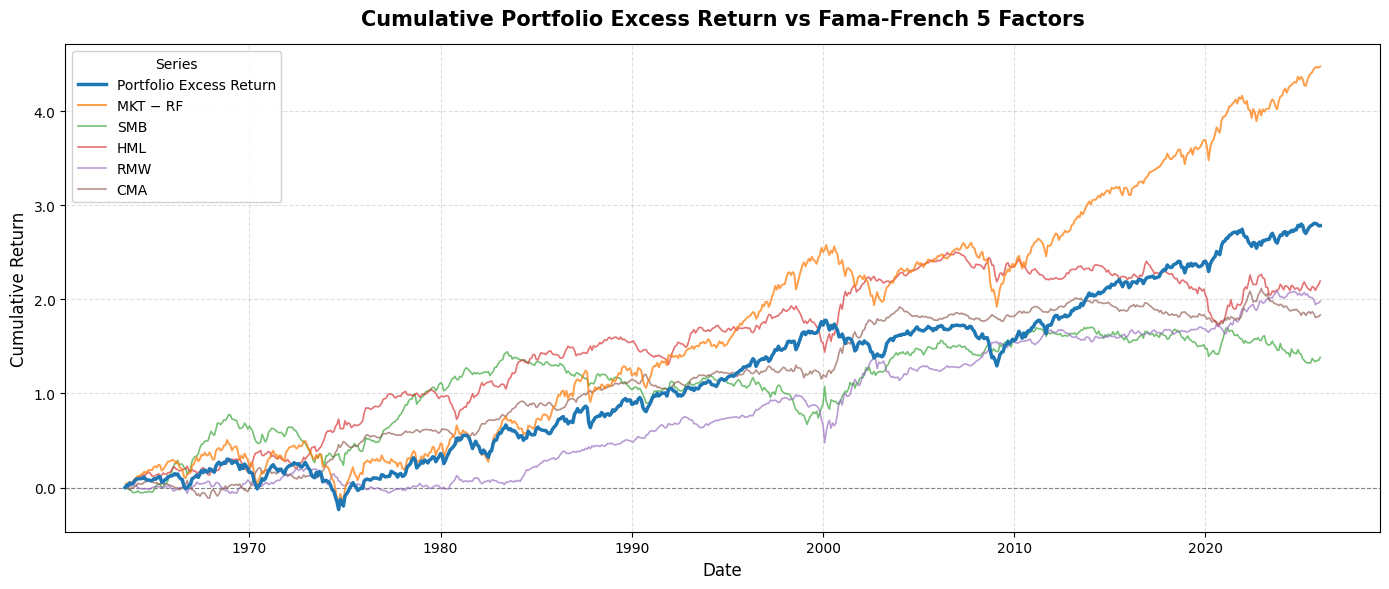

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLS = ["Portfolio_Excess", "MKT_RF", "SMB", "HML", "RMW", "CMA"]

# ── 1. Deduplicate index (fixes double blue line) ────────────────────────────
df_clean = df[~df.index.duplicated(keep='first')].copy()

# ── 2. Diagnostic: print first few rows to understand what's in the columns ──
print("=== First 5 rows of raw data ===")
print(df_clean[COLS].head())
print("\n=== Are values already cumulative? (std check) ===")
print("Raw std:", df_clean[COLS].std().round(4))
print("Diff std:", df_clean[COLS].diff().std().round(4))

# ── 3. Decide whether to cumsum or not ───────────────────────────────────────
#    If values are already cumulative, skip cumsum. If they are period returns
#    (small values near 0), apply cumsum. Adjust this threshold as needed.
raw_std = df_clean[COLS].std()
is_already_cumulative = (raw_std > 0.5).all()  # period returns are tiny (< 0.05 std typically)

if is_already_cumulative:
    print("\n⚠️  Data appears already cumulative — skipping cumsum()")
    cumulative = df_clean[COLS].copy()
else:
    print("\n✅  Data appears to be period returns — applying cumsum()")
    cumulative = df_clean[COLS].cumsum()

# ── 4. Normalize: force all series to start at 0 ────────────────────────────
cumulative = cumulative - cumulative.iloc[0]

# ── 5. Style map ─────────────────────────────────────────────────────────────
style = {
    "Portfolio_Excess": dict(label="Portfolio Excess Return", color="#1f77b4", lw=2.5, alpha=1.0,  zorder=5),
    "MKT_RF":           dict(label="MKT − RF",               color="#ff7f0e", lw=1.4, alpha=0.75, zorder=4),
    "SMB":              dict(label="SMB",                     color="#2ca02c", lw=1.2, alpha=0.65, zorder=3),
    "HML":              dict(label="HML",                     color="#d62728", lw=1.2, alpha=0.65, zorder=3),
    "RMW":              dict(label="RMW",                     color="#9467bd", lw=1.2, alpha=0.65, zorder=3),
    "CMA":              dict(label="CMA",                     color="#8c564b", lw=1.2, alpha=0.65, zorder=3),
}

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for col in COLS:
    s = style[col]
    ax.plot(cumulative.index, cumulative[col],
            label=s["label"], color=s["color"],
            linewidth=s["lw"], alpha=s["alpha"], zorder=s["zorder"])

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_title("Cumulative Portfolio Excess Return vs Fama-French 5 Factors",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative Return", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.grid(True, linestyle="--", alpha=0.4)
ax.tick_params(axis="both", labelsize=10)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9,
          edgecolor="#cccccc", title="Series", title_fontsize=10)

plt.tight_layout()
plt.show()

The chart shows the cumulative excess returns of the portfolio and the five Fama-French factors from the late 1960s to 2025. The portfolio (blue) generally follows the factor returns, as expected from its construction. MKT-RF (orange) outperforms, ending near 4.5, reflecting the long-run equity risk premium. The portfolio finishes around 2.8, above HML, RMW, CMA, and SMB, which range from 1.3 to 2.2.

The portfolio dips briefly below zero in the mid-1970s and suffers its largest drawdown during the 2008–2009 Global Financial Crisis, a pattern shared across most series. From 2010 onward, the portfolio accelerates, narrowing the gap with MKT-RF, showing growing rewards from factor tilts. Overall, it achieves strong long-run excess returns with lower volatility than the market factor alone, reflecting its diversified multi-factor design.

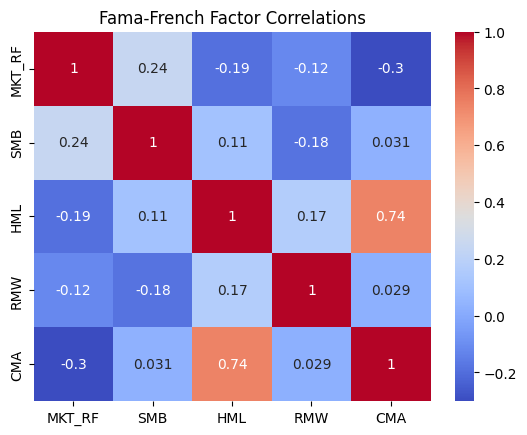

In [33]:
import seaborn as sns

sns.heatmap(df[["MKT_RF", "SMB", "HML", "RMW", "CMA"]].corr(), annot=True, cmap="coolwarm")
plt.title("Fama-French Factor Correlations")
plt.show()

This correlation matrix is important for understanding **diversification across factors**. Low or negative correlations between factors, like the small correlation between SMB and RMW (-0.18) or between MKT_RF and CMA (-0.30), mean that these factors behave differently over time. By combining factors that are not strongly correlated, a portfolio can reduce overall risk because losses in one factor may be offset by gains in another. Conversely, factors that are highly correlated, like HML and CMA (0.74), move more closely together, so combining them provides less diversification benefit. Understanding these relationships helps investors build portfolios that capture multiple sources of returns while managing risk more effectively.
